**Solow Model**

Steady State capital : $(\frac{s}{δ})^{\frac{1}{1-\alpha}}$

Steady State output : $(\frac{s}{δ})^{\frac{\alpha}{1-\alpha}}$

# Import packages and Parameters

In [1]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 5)  #set default figure size
import numpy as np
import pandas as pd
import numba

from scipy.optimize import fsolve

In [2]:
## parameters in the model

alpha = 0.33
delta = 0.05
s= 0.2


# Steady State

In [3]:
### steady state using the analytical solution
def solow_steadystate(s,alpha,delta):
    k_star = (s/delta)**(1/(1-alpha))
    y_star = (s/delta)**(alpha/(1-alpha))
    print("steady state value of capital and output are respectively",np.round(k_star,3),np.round(y_star,3))
    return k_star,y_star

In [ ]:
k_star,y_star = solow_steadystate(s,alpha,delta)

steady state value of capital and output are respectively 7.918 1.979


In [4]:
# Use fsolve to find the steady state (Newton-Raphson method using initial guess)

# Define the function for which we want to find the root: s * k^alpha - delta * k = 0
def equation_to_solve(k):
  return 0.2 * k**0.33 - 0.05 * k

### inital guess except 0
initial_guess = 2
%time
steady_state_k = fsolve(equation_to_solve, initial_guess)

print("The steady state value of 'k' found by fsolve is:", steady_state_k[0])

CPU times: user 4 µs, sys: 1 µs, total: 5 µs
Wall time: 7.63 µs
The steady state value of 'k' found by fsolve is: 7.917662800852012


# Dynamics



In [5]:
## function for describing dynamics of the solow model
def solow_dynamics_horizon(get_g,T,s,alpha,delta):

  ## initial condition
  k =[0.9*steady_state_k[0]]
  k_g =[]
  y = [k[0]**alpha]
  y_g=[]
  ## level values of capital and output and growth rates of capital and output
  for i in range(T):
    k.append(0.2 * k[i]**0.33 + (1 - 0.05)* k[i])
    k_g.append(k[i]/k[i-1]-1)
    y.append(k[i]**alpha)
    y_g.append(y[i]/y[i-1]-1)
  ## get_g
  if get_g ==1:
    return k_g,y_g
  else:
    return k,y


In [6]:
%time
level_k_y = solow_dynamics_horizon(0,100,s,alpha,delta)
growth_k_y = solow_dynamics_horizon(1,100,s,alpha,delta)

CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 5.72 µs


In [ ]:
print(len(level_k_y[0]),len(level_k_y[1]), len(growth_k_y[0]),len(growth_k_y[1]))

101 101 100 100


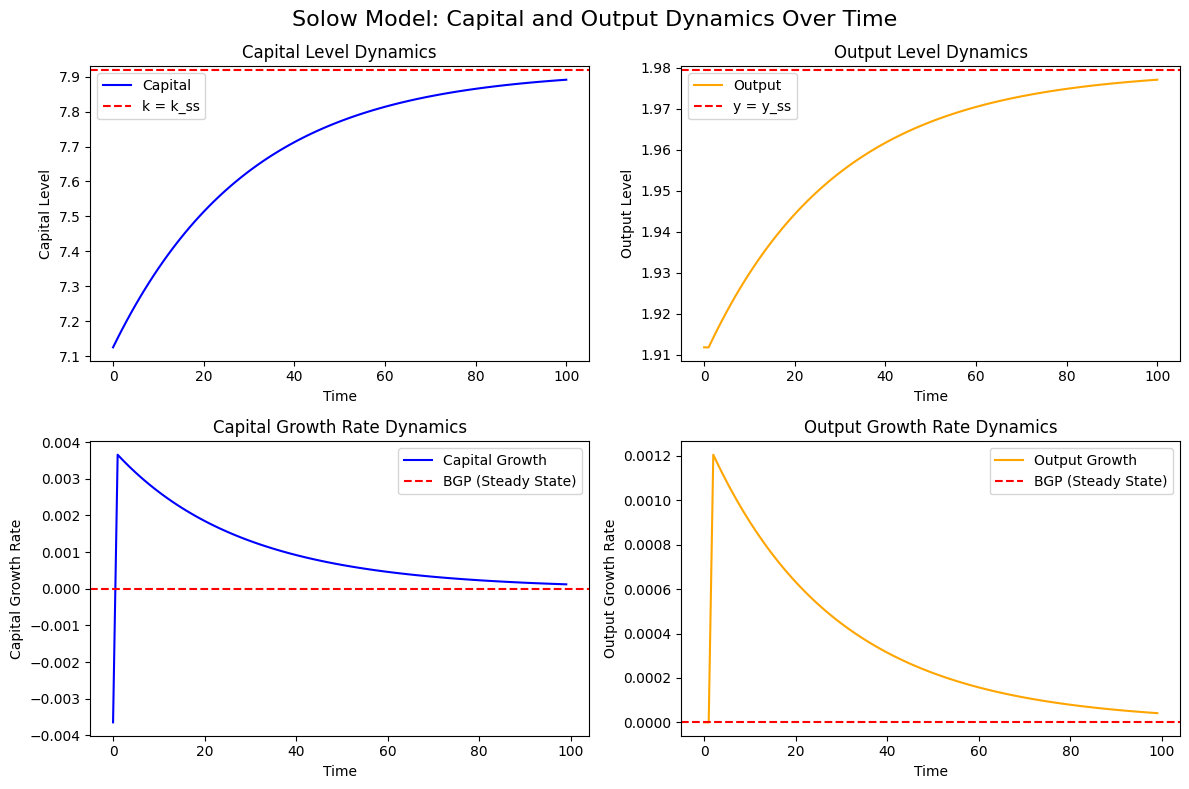

In [ ]:
#### plot the capital and output dynamics
fig, axes = plt.subplots(2, 2, figsize=(12, 8)) # Create a figure with 2x2 subplots

# Plot Capital levels dynamics on the first subplot (top left)
axes[0, 0].plot(level_k_y[0], label="Capital", color = "blue")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Capital Level")
axes[0, 0].set_title("Capital Level Dynamics")
axes[0, 0].legend()
axes[0, 0].axhline(y=k_star, color='r', linestyle='--', label='k = k_ss') # Add horizontal line for steady state capital
axes[0, 0].legend()

# Plot Output levels dynamics on the second subplot (top right)
axes[0, 1].plot(level_k_y[1], label="Output", color='orange')
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Output Level")
axes[0, 1].set_title("Output Level Dynamics")
axes[0, 1].legend()
axes[0, 1].axhline(y=y_star, color='r', linestyle='--', label='y = y_ss') # Add horizontal line for steady state output
axes[0, 1].legend()

# Plot Capital growth rate dynamics on the third subplot (bottom left)
axes[1, 0].plot(growth_k_y[0], label="Capital Growth", color = "blue")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Capital Growth Rate")
axes[1, 0].set_title("Capital Growth Rate Dynamics")
axes[1, 0].legend()
axes[1, 0].axhline(y=0, color='r', linestyle='--', label='BGP (Steady State)') # Steady state growth rate is 0
axes[1, 0].legend()

# Plot Output growth rate dynamics on the fourth subplot (bottom right)
axes[1, 1].plot(growth_k_y[1], label="Output Growth", color = "orange")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Output Growth Rate")
axes[1, 1].set_title("Output Growth Rate Dynamics")
axes[1, 1].legend()
axes[1, 1].axhline(y=0, color='r', linestyle='--', label='BGP (Steady State)') # Steady state growth rate is 0
axes[1, 1].legend()


# Add a main title for the figure
fig.suptitle("Solow Model: Capital and Output Dynamics Over Time", fontsize=16)

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

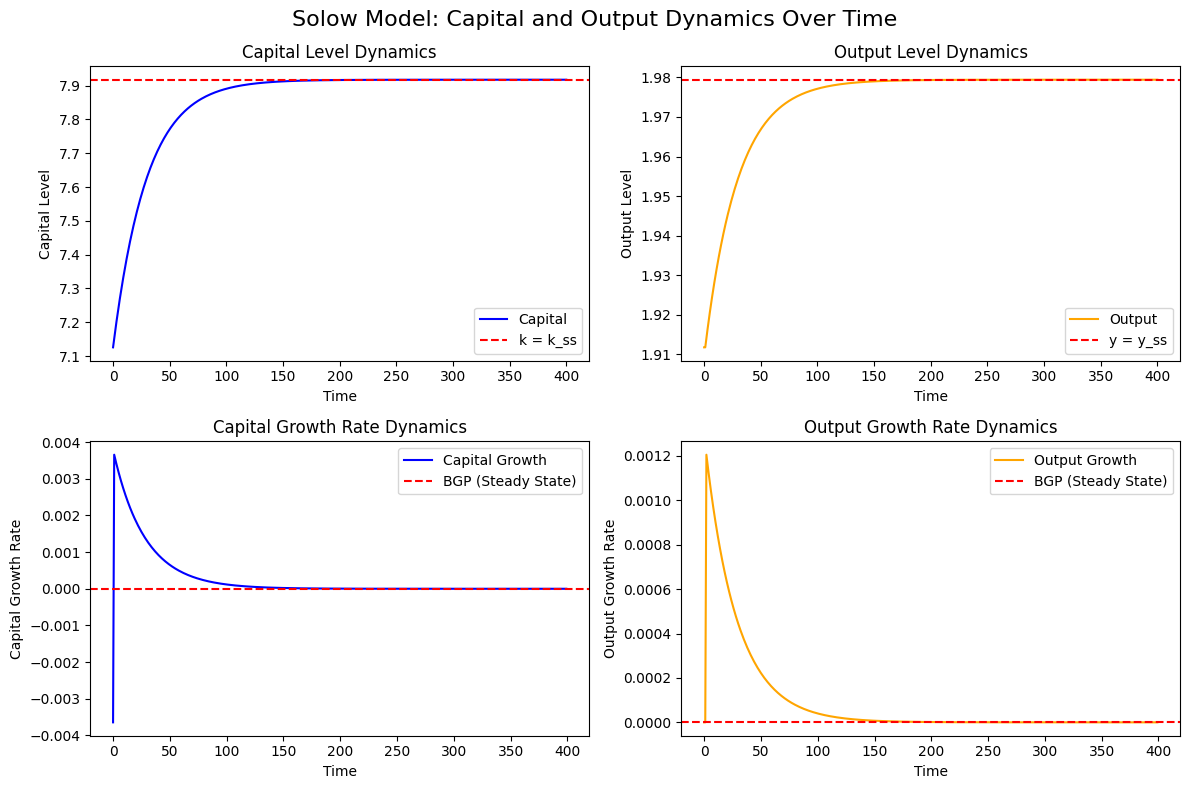

In [ ]:
#### plot the capital and output dynamics
fig, axes = plt.subplots(2, 2, figsize=(12, 8)) # Create a figure with 2x2 subplots

# Plot Capital levels dynamics on the first subplot (top left)
axes[0, 0].plot(level_k_y[0], label="Capital", color = "blue")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Capital Level")
axes[0, 0].set_title("Capital Level Dynamics")
axes[0, 0].legend()
axes[0, 0].axhline(y=k_star, color='r', linestyle='--', label='k = k_ss') # Add horizontal line for steady state capital
axes[0, 0].legend()

# Plot Output levels dynamics on the second subplot (top right)
axes[0, 1].plot(level_k_y[1], label="Output", color='orange')
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Output Level")
axes[0, 1].set_title("Output Level Dynamics")
axes[0, 1].legend()
axes[0, 1].axhline(y=y_star, color='r', linestyle='--', label='y = y_ss') # Add horizontal line for steady state output
axes[0, 1].legend()

# Plot Capital growth rate dynamics on the third subplot (bottom left)
axes[1, 0].plot(growth_k_y[0], label="Capital Growth", color = "blue")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Capital Growth Rate")
axes[1, 0].set_title("Capital Growth Rate Dynamics")
axes[1, 0].legend()
axes[1, 0].axhline(y=0, color='r', linestyle='--', label='BGP (Steady State)') # Steady state growth rate is 0
axes[1, 0].legend()

# Plot Output growth rate dynamics on the fourth subplot (bottom right)
axes[1, 1].plot(growth_k_y[1], label="Output Growth", color = "orange")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Output Growth Rate")
axes[1, 1].set_title("Output Growth Rate Dynamics")
axes[1, 1].legend()
axes[1, 1].axhline(y=0, color='r', linestyle='--', label='BGP (Steady State)') # Steady state growth rate is 0
axes[1, 1].legend()


# Add a main title for the figure
fig.suptitle("Solow Model: Capital and Output Dynamics Over Time", fontsize=16)

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

In [ ]:
# Install necessary packages if you haven't already
# using Pkg
# Pkg.add("Plots")
# Pkg.add("LsqFit") # for fsolve equivalent
# Pkg.add("BenchmarkTools") # for @time equivalent
# Pkg.add("Printf") # for printing with formatting

using Plots
using LsqFit # for fsolve equivalent
using BenchmarkTools # for @time equivalent
using Printf # for printing with formatting

In [ ]:
## parameters in the model

alpha = 0.33
delta = 0.05
s= 0.2

In [ ]:
### steady state using the analytical solution
function solow_steadystate(s, alpha, delta)
    k_star = (s / delta)^(1 / (1 - alpha))
    y_star = (s / delta)^(alpha / (1 - alpha))
    @printf("steady state value of capital and output are respectively %.3f %.3f\n", k_star, y_star)
    return k_star, y_star
end

In [ ]:
k_star, y_star = solow_steadystate(s, alpha, delta)

In [ ]:
# Use LsqFit.levenberg_marquardt to find the steady state (equivalent to fsolve)

# Define the function for which we want to find the root: s * k^alpha - delta * k = 0
equation_to_solve(k, p) = p[1] * k[1]^p[2] - p[3] * k[1]

### initial guess except 0
initial_guess = [2.0] # LsqFit works with arrays
params = [s, alpha, delta]

@time begin
    # We are looking for the root, so the target is 0
    result = LsqFit.levenberg_marquardt(equation_to_solve, initial_guess, params, 0)
    steady_state_k = result.param[1]
end

@printf("The steady state value of 'k' found by LsqFit is: %.12f\n", steady_state_k)

In [ ]:
## function for describing dynamics of the solow model
function solow_dynamics_horizon(get_g, T, s, alpha, delta, steady_state_k)

  ## initial condition
  k = [0.9 * steady_state_k]
  k_g = Float64[]
  y = [k[1]^alpha]
  y_g = Float64[]

  ## level values of capital and output and growth rates of capital and output
  for i in 1:T
    push!(k, s * k[i]^alpha + (1 - delta) * k[i])
    if i > 1
        push!(k_g, k[i] / k[i-1] - 1)
        push!(y_g, y[i] / y[i-1] - 1)
    else
        # Handle the first period where growth rate is not well-defined from previous period
        push!(k_g, 0.0) # Or NaN, depending on desired representation
        push!(y_g, 0.0) # Or NaN
    end
    push!(y, k[i+1]^alpha) # y is calculated based on the next period's capital
  end

  ## get_g
  if get_g == 1
    return k_g, y_g
  else
    return k, y
  end

end

In [ ]:
@time begin
    level_k_y = solow_dynamics_horizon(0, 100, s, alpha, delta, steady_state_k)
    growth_k_y = solow_dynamics_horizon(1, 100, s, alpha, delta, steady_state_k)
end

In [ ]:
println(length(level_k_y[1]), " ", length(level_k_y[2]), " ", length(growth_k_y[1]), " ", length(growth_k_y[2]))

In [ ]:
#### plot the capital and output dynamics
# Create a figure with 2x2 subplots
p1 = plot(level_k_y[1], label="Capital", color = :blue, xlabel="Time", ylabel="Capital Level", title="Capital Level Dynamics")
hline!([k_star], color=:red, linestyle=:dash, label="k = k_ss")

p2 = plot(level_k_y[2], label="Output", color = :orange, xlabel="Time", ylabel="Output Level", title="Output Level Dynamics")
hline!([y_star], color=:red, linestyle=:dash, label="y = y_ss")

p3 = plot(growth_k_y[1], label="Capital Growth", color = :blue, xlabel="Time", ylabel="Capital Growth Rate", title="Capital Growth Rate Dynamics")
hline!([0], color=:red, linestyle=:dash, label="BGP (Steady State)")

p4 = plot(growth_k_y[2], label="Output Growth", color = :orange, xlabel="Time", ylabel="Output Growth Rate", title="Output Growth Rate Dynamics")
hline!([0], color=:red, linestyle=:dash, label="BGP (Steady State)")

# Add a main title for the figure and arrange subplots
plot(p1, p2, p3, p4, layout=(2, 2), plot_title="Solow Model: Capital and Output Dynamics Over Time", size=(800, 600), legend=:bottomright)

In [8]:
## function to determine the speed of convergence for the model

def solow_convergence(s,alpha,delta,k_0,tol=10**-6):
  ## initial condition
  i=0
  k = k_0
  k_star = (s/delta)**(1/(1-alpha))
  T=0
  %time
  while abs(k-k_star) > tol:
    k = (s * k**alpha + (1 - delta)* k)
    T=T+1
    i=i+1
  print("The economy took {} periods to converge to steady state".format(T))
  return T


In [10]:
solow_convergence(s,alpha,delta,0.98*steady_state_k[0])

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 6.91 µs
The economy took 352 periods to converge to steady state


352

In [ ]:
0.9*steady_state_k[0]

np.float64(7.125896520766811)